In [1]:
from google.colab import files
uploaded = files.upload()
# Upload all 6 CSV files

Saving 01_awareness_data.csv to 01_awareness_data.csv
Saving 02_consideration_data.csv to 02_consideration_data.csv
Saving 03_intent_data.csv to 03_intent_data.csv
Saving 04_conversion_data.csv to 04_conversion_data.csv
Saving 05_retention_data.csv to 05_retention_data.csv
Saving 06_full_funnel_summary.csv to 06_full_funnel_summary.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from matplotlib.ticker import FuncFormatter
import warnings
warnings.filterwarnings('ignore')

COLORS = {
    'awareness':     '#1A5276',
    'consideration': '#2E86C1',
    'intent':        '#85C1E9',
    'conversion':    '#27AE60',
    'retention':     '#E74C3C'
}

plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

# Load data
awareness     = pd.read_csv('01_awareness_data.csv',     parse_dates=['date'])
consideration = pd.read_csv('02_consideration_data.csv', parse_dates=['date'])
intent        = pd.read_csv('03_intent_data.csv',        parse_dates=['date'])
conversion    = pd.read_csv('04_conversion_data.csv',    parse_dates=['date'])
retention     = pd.read_csv('05_retention_data.csv',     parse_dates=['date'])
funnel        = pd.read_csv('06_full_funnel_summary.csv',parse_dates=['date'])

print("✅ All data loaded!")

✅ All data loaded!


#  Stage 1: Awareness Deep Dive:

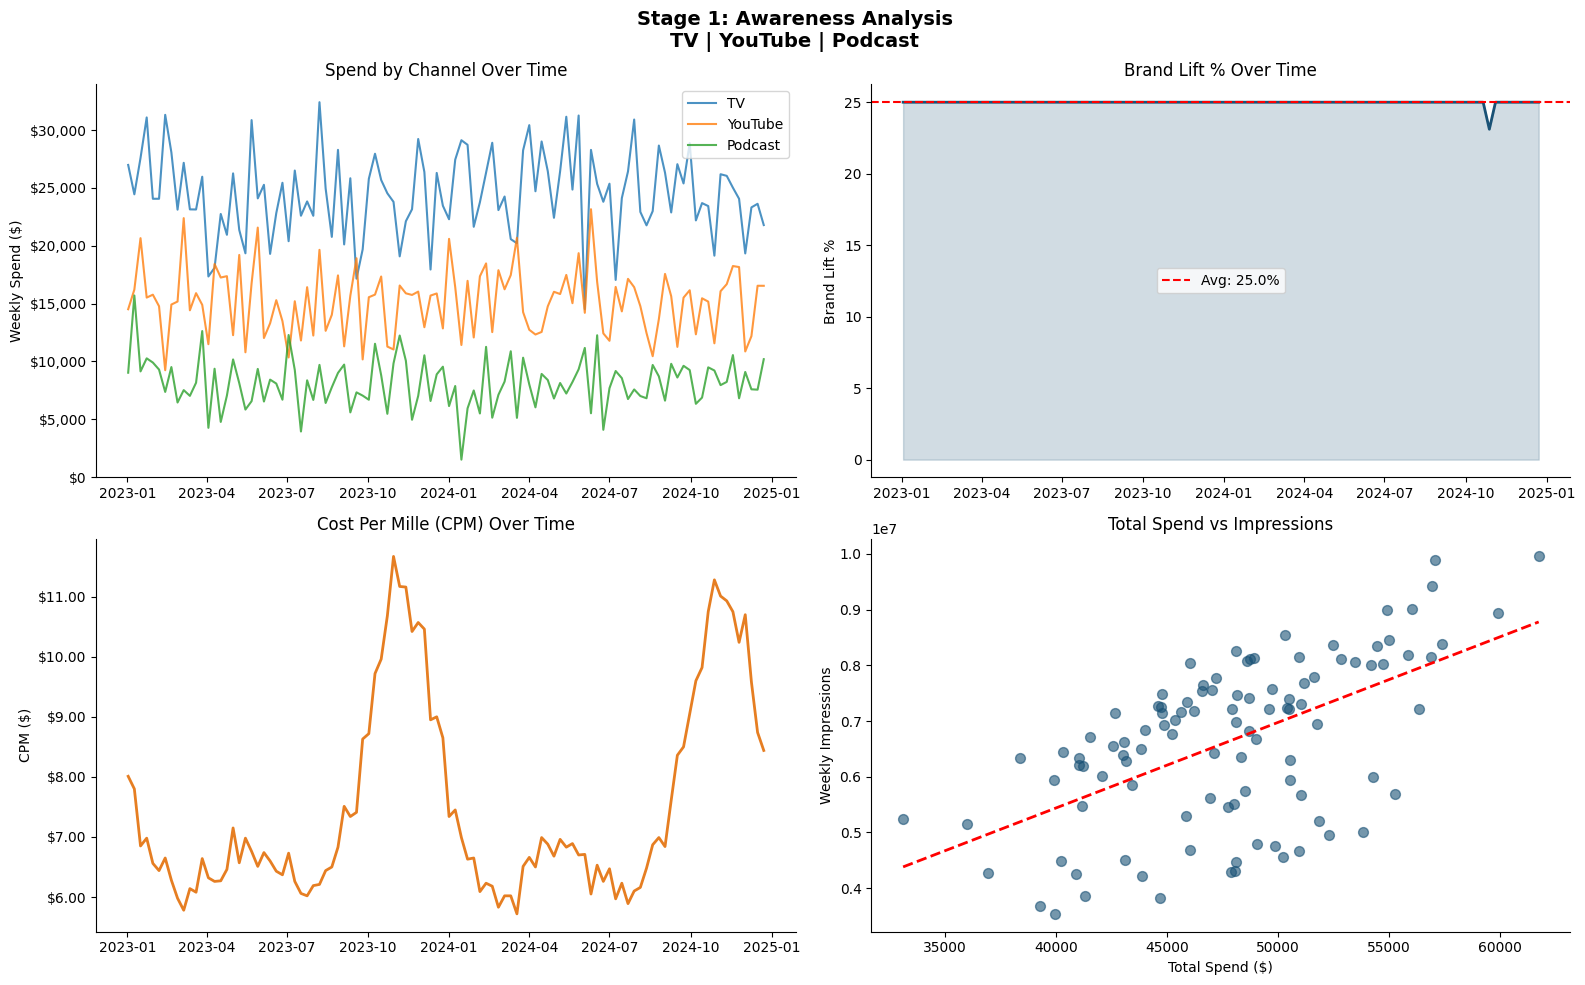

✅ Awareness analysis saved!


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Stage 1: Awareness Analysis\nTV | YouTube | Podcast',
             fontsize=14, fontweight='bold')

# Spend by channel over time
for col, label, color in [
    ('tv_spend',      'TV',      '#1A5276'),
    ('youtube_spend', 'YouTube', '#2E86C1'),
    ('podcast_spend', 'Podcast', '#85C1E9')
]:
    axes[0,0].plot(awareness['date'], awareness[col],
                   label=label, linewidth=1.5, alpha=0.8)
axes[0,0].set_title('Spend by Channel Over Time')
axes[0,0].set_ylabel('Weekly Spend ($)')
axes[0,0].legend()
axes[0,0].yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Brand lift trend
axes[0,1].plot(awareness['date'], awareness['brand_lift_pct'],
               color=COLORS['awareness'], linewidth=2)
axes[0,1].fill_between(awareness['date'], awareness['brand_lift_pct'],
                        alpha=0.2, color=COLORS['awareness'])
axes[0,1].axhline(awareness['brand_lift_pct'].mean(),
                   color='red', linestyle='--', linewidth=1.5,
                   label=f"Avg: {awareness['brand_lift_pct'].mean():.1f}%")
axes[0,1].set_title('Brand Lift % Over Time')
axes[0,1].set_ylabel('Brand Lift %')
axes[0,1].legend()

# CPM trend
axes[1,0].plot(awareness['date'], awareness['cpm'],
               color='#E67E22', linewidth=2)
axes[1,0].set_title('Cost Per Mille (CPM) Over Time')
axes[1,0].set_ylabel('CPM ($)')
axes[1,0].yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x:.2f}'))

# Spend vs Impressions scatter
axes[1,1].scatter(awareness['total_spend'],
                  awareness['impressions'],
                  color=COLORS['awareness'], alpha=0.6, s=50)
z = np.polyfit(awareness['total_spend'],
               awareness['impressions'], 1)
p = np.poly1d(z)
axes[1,1].plot(sorted(awareness['total_spend']),
               p(sorted(awareness['total_spend'])),
               color='red', linewidth=2, linestyle='--')
axes[1,1].set_title('Total Spend vs Impressions')
axes[1,1].set_xlabel('Total Spend ($)')
axes[1,1].set_ylabel('Weekly Impressions')

plt.tight_layout()
plt.savefig('05_awareness_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Awareness analysis saved!")

# Stage 2: Consideration Deep Dive:

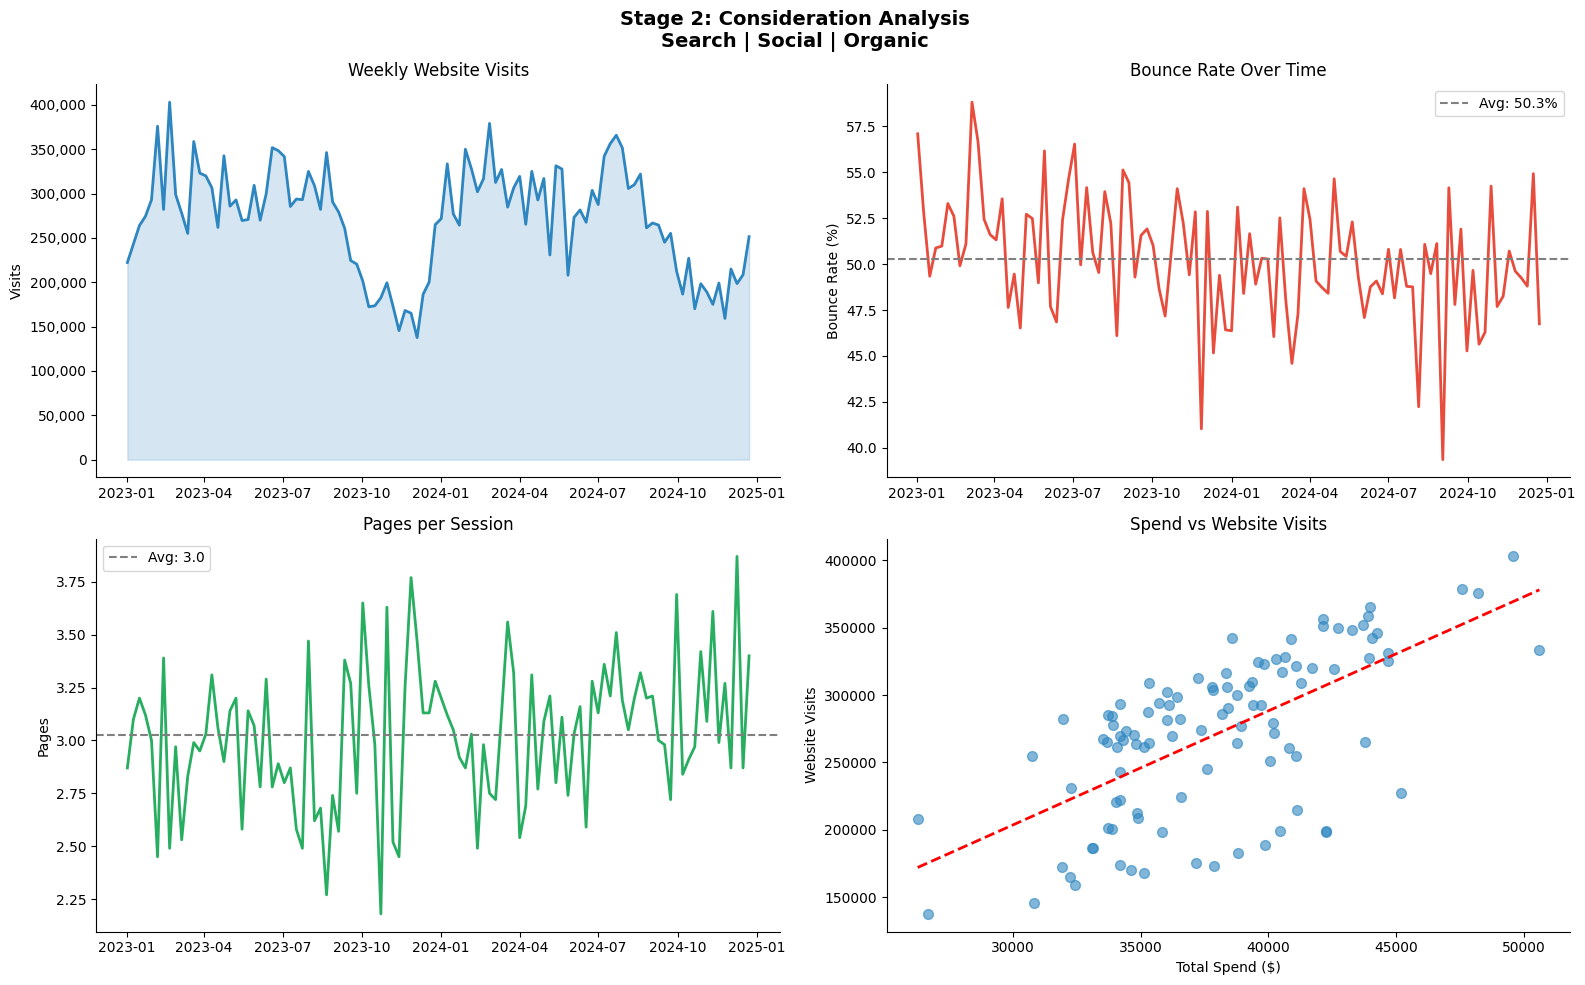

✅ Consideration analysis saved!


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Stage 2: Consideration Analysis\nSearch | Social | Organic',
             fontsize=14, fontweight='bold')

# Website visits trend
axes[0,0].plot(consideration['date'],
               consideration['website_visits'],
               color=COLORS['consideration'], linewidth=2)
axes[0,0].fill_between(consideration['date'],
                        consideration['website_visits'],
                        alpha=0.2, color=COLORS['consideration'])
axes[0,0].set_title('Weekly Website Visits')
axes[0,0].set_ylabel('Visits')
axes[0,0].yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Bounce rate trend
axes[0,1].plot(consideration['date'],
               consideration['bounce_rate'],
               color='#E74C3C', linewidth=2)
axes[0,1].axhline(consideration['bounce_rate'].mean(),
                   color='gray', linestyle='--',
                   label=f"Avg: {consideration['bounce_rate'].mean():.1f}%")
axes[0,1].set_title('Bounce Rate Over Time')
axes[0,1].set_ylabel('Bounce Rate (%)')
axes[0,1].legend()

# Pages per session
axes[1,0].plot(consideration['date'],
               consideration['pages_per_session'],
               color='#27AE60', linewidth=2)
axes[1,0].axhline(consideration['pages_per_session'].mean(),
                   color='gray', linestyle='--',
                   label=f"Avg: {consideration['pages_per_session'].mean():.1f}")
axes[1,0].set_title('Pages per Session')
axes[1,0].set_ylabel('Pages')
axes[1,0].legend()

# Spend vs Website visits
axes[1,1].scatter(consideration['total_spend'],
                  consideration['website_visits'],
                  color=COLORS['consideration'], alpha=0.6, s=50)
z = np.polyfit(consideration['total_spend'],
               consideration['website_visits'], 1)
p = np.poly1d(z)
axes[1,1].plot(sorted(consideration['total_spend']),
               p(sorted(consideration['total_spend'])),
               color='red', linewidth=2, linestyle='--')
axes[1,1].set_title('Spend vs Website Visits')
axes[1,1].set_xlabel('Total Spend ($)')
axes[1,1].set_ylabel('Website Visits')

plt.tight_layout()
plt.savefig('06_consideration_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Consideration analysis saved!")

#  Stage 3: Intent Deep Dive:

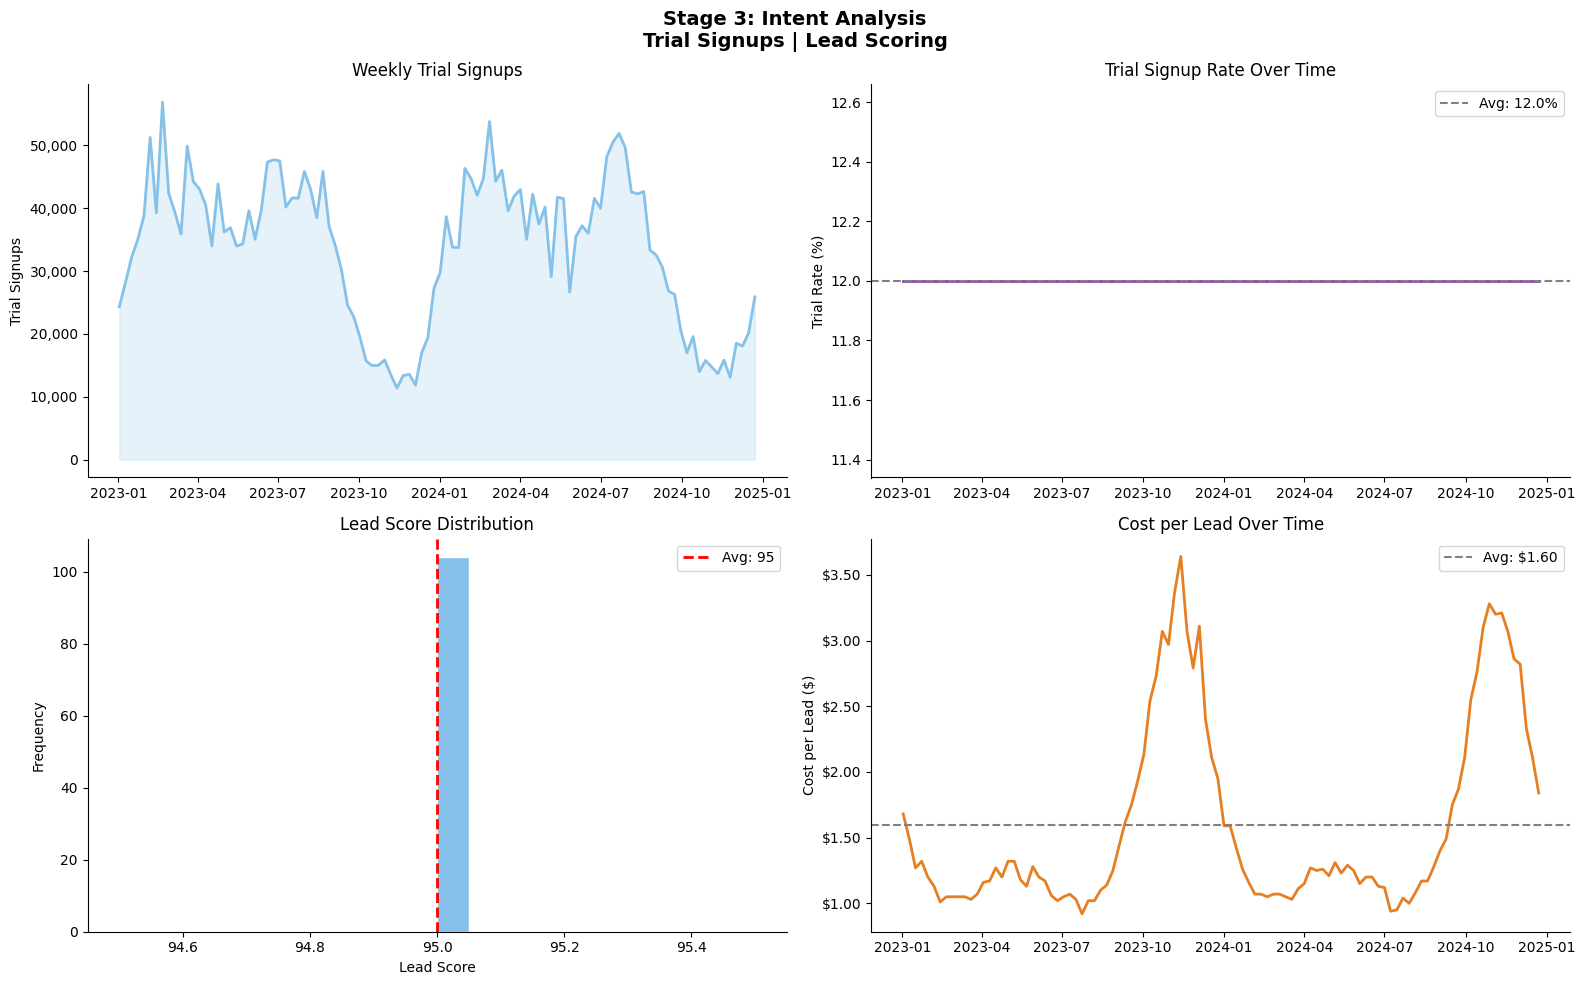

✅ Intent analysis saved!


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Stage 3: Intent Analysis\nTrial Signups | Lead Scoring',
             fontsize=14, fontweight='bold')

# Trial signups trend
axes[0,0].plot(intent['date'], intent['trial_signups'],
               color=COLORS['intent'], linewidth=2)
axes[0,0].fill_between(intent['date'], intent['trial_signups'],
                        alpha=0.2, color=COLORS['intent'])
axes[0,0].set_title('Weekly Trial Signups')
axes[0,0].set_ylabel('Trial Signups')
axes[0,0].yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Trial rate trend
axes[0,1].plot(intent['date'], intent['trial_rate_pct'],
               color='#8E44AD', linewidth=2)
axes[0,1].axhline(intent['trial_rate_pct'].mean(),
                   color='gray', linestyle='--',
                   label=f"Avg: {intent['trial_rate_pct'].mean():.1f}%")
axes[0,1].set_title('Trial Signup Rate Over Time')
axes[0,1].set_ylabel('Trial Rate (%)')
axes[0,1].legend()

# Lead score distribution
axes[1,0].hist(intent['avg_lead_score'], bins=20,
               color=COLORS['intent'], edgecolor='white')
axes[1,0].axvline(intent['avg_lead_score'].mean(),
                   color='red', linestyle='--', linewidth=2,
                   label=f"Avg: {intent['avg_lead_score'].mean():.0f}")
axes[1,0].set_title('Lead Score Distribution')
axes[1,0].set_xlabel('Lead Score')
axes[1,0].set_ylabel('Frequency')
axes[1,0].legend()

# Cost per lead trend
axes[1,1].plot(intent['date'], intent['cost_per_lead'],
               color='#E67E22', linewidth=2)
axes[1,1].axhline(intent['cost_per_lead'].mean(),
                   color='gray', linestyle='--',
                   label=f"Avg: ${intent['cost_per_lead'].mean():.2f}")
axes[1,1].set_title('Cost per Lead Over Time')
axes[1,1].set_ylabel('Cost per Lead ($)')
axes[1,1].yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x:.2f}'))
axes[1,1].legend()

plt.tight_layout()
plt.savefig('07_intent_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Intent analysis saved!")

 # Stage 4: Conversion Deep Dive:

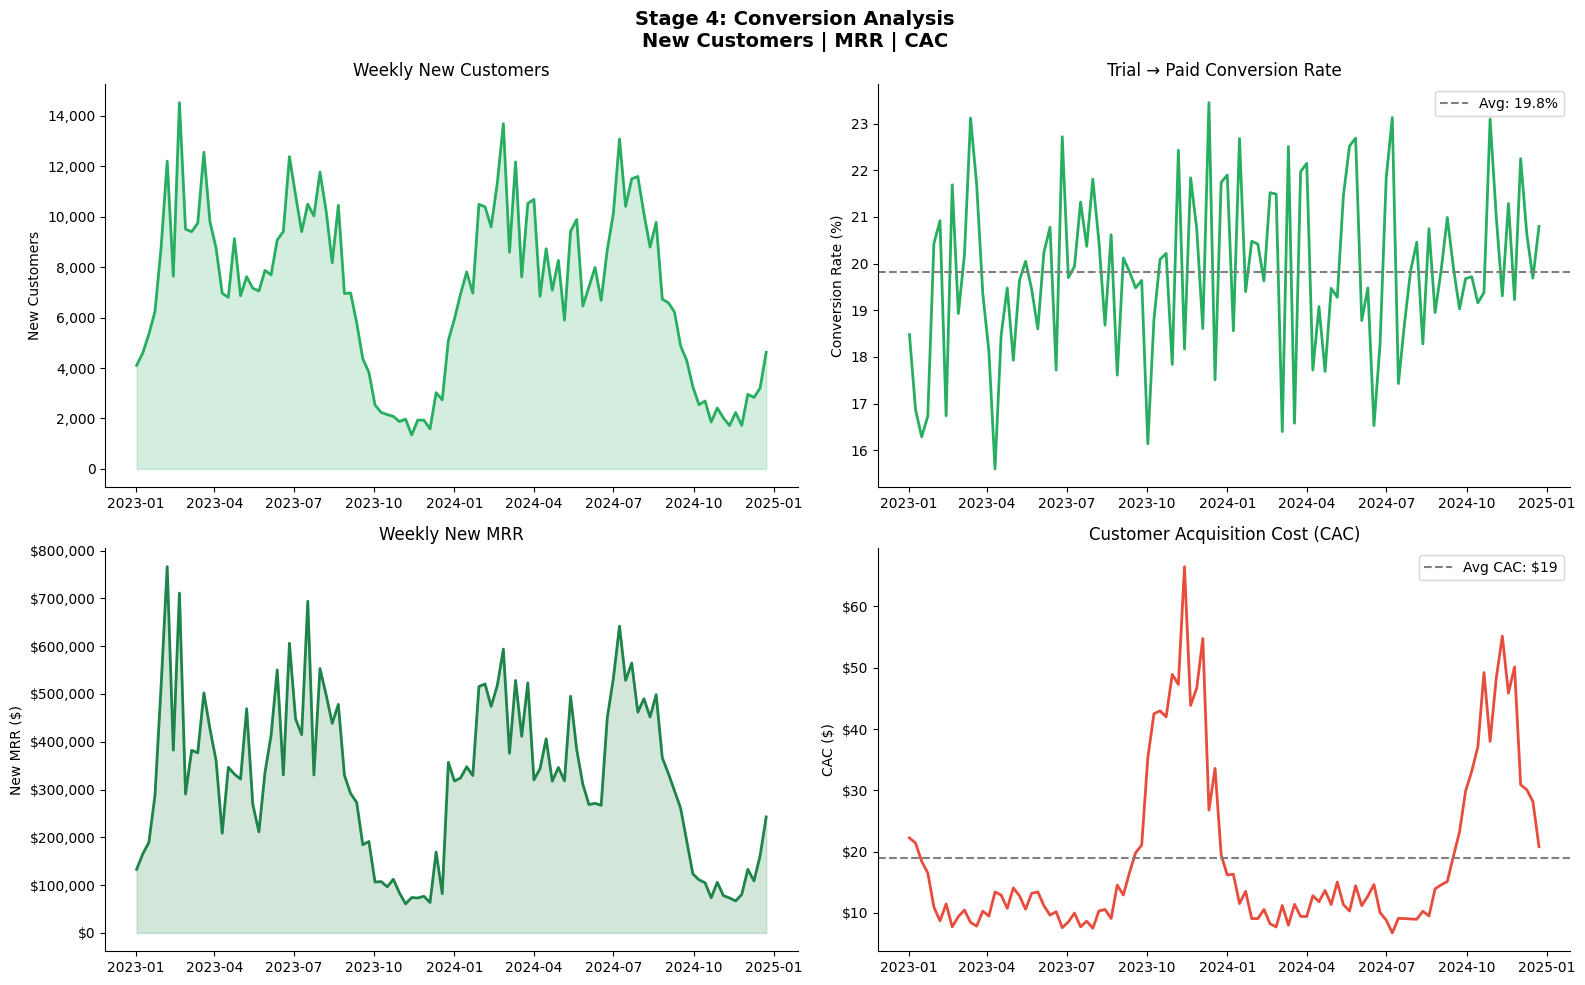

✅ Conversion analysis saved!


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Stage 4: Conversion Analysis\nNew Customers | MRR | CAC',
             fontsize=14, fontweight='bold')

# New customers trend
axes[0,0].plot(conversion['date'], conversion['new_customers'],
               color=COLORS['conversion'], linewidth=2)
axes[0,0].fill_between(conversion['date'], conversion['new_customers'],
                        alpha=0.2, color=COLORS['conversion'])
axes[0,0].set_title('Weekly New Customers')
axes[0,0].set_ylabel('New Customers')
axes[0,0].yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Trial to paid rate
axes[0,1].plot(conversion['date'],
               conversion['trial_to_paid_pct'],
               color='#27AE60', linewidth=2)
axes[0,1].axhline(conversion['trial_to_paid_pct'].mean(),
                   color='gray', linestyle='--',
                   label=f"Avg: {conversion['trial_to_paid_pct'].mean():.1f}%")
axes[0,1].set_title('Trial → Paid Conversion Rate')
axes[0,1].set_ylabel('Conversion Rate (%)')
axes[0,1].legend()

# MRR trend
axes[1,0].plot(conversion['date'], conversion['new_mrr'],
               color='#1E8449', linewidth=2)
axes[1,0].fill_between(conversion['date'], conversion['new_mrr'],
                        alpha=0.2, color='#1E8449')
axes[1,0].set_title('Weekly New MRR')
axes[1,0].set_ylabel('New MRR ($)')
axes[1,0].yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x:,.0f}'))

# CAC trend
axes[1,1].plot(conversion['date'], conversion['cac'],
               color='#E74C3C', linewidth=2)
axes[1,1].axhline(conversion['cac'].mean(),
                   color='gray', linestyle='--',
                   label=f"Avg CAC: ${conversion['cac'].mean():.0f}")
axes[1,1].set_title('Customer Acquisition Cost (CAC)')
axes[1,1].set_ylabel('CAC ($)')
axes[1,1].yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x:.0f}'))
axes[1,1].legend()

plt.tight_layout()
plt.savefig('08_conversion_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Conversion analysis saved!")

#  Stage 5: Retention Deep Dive:

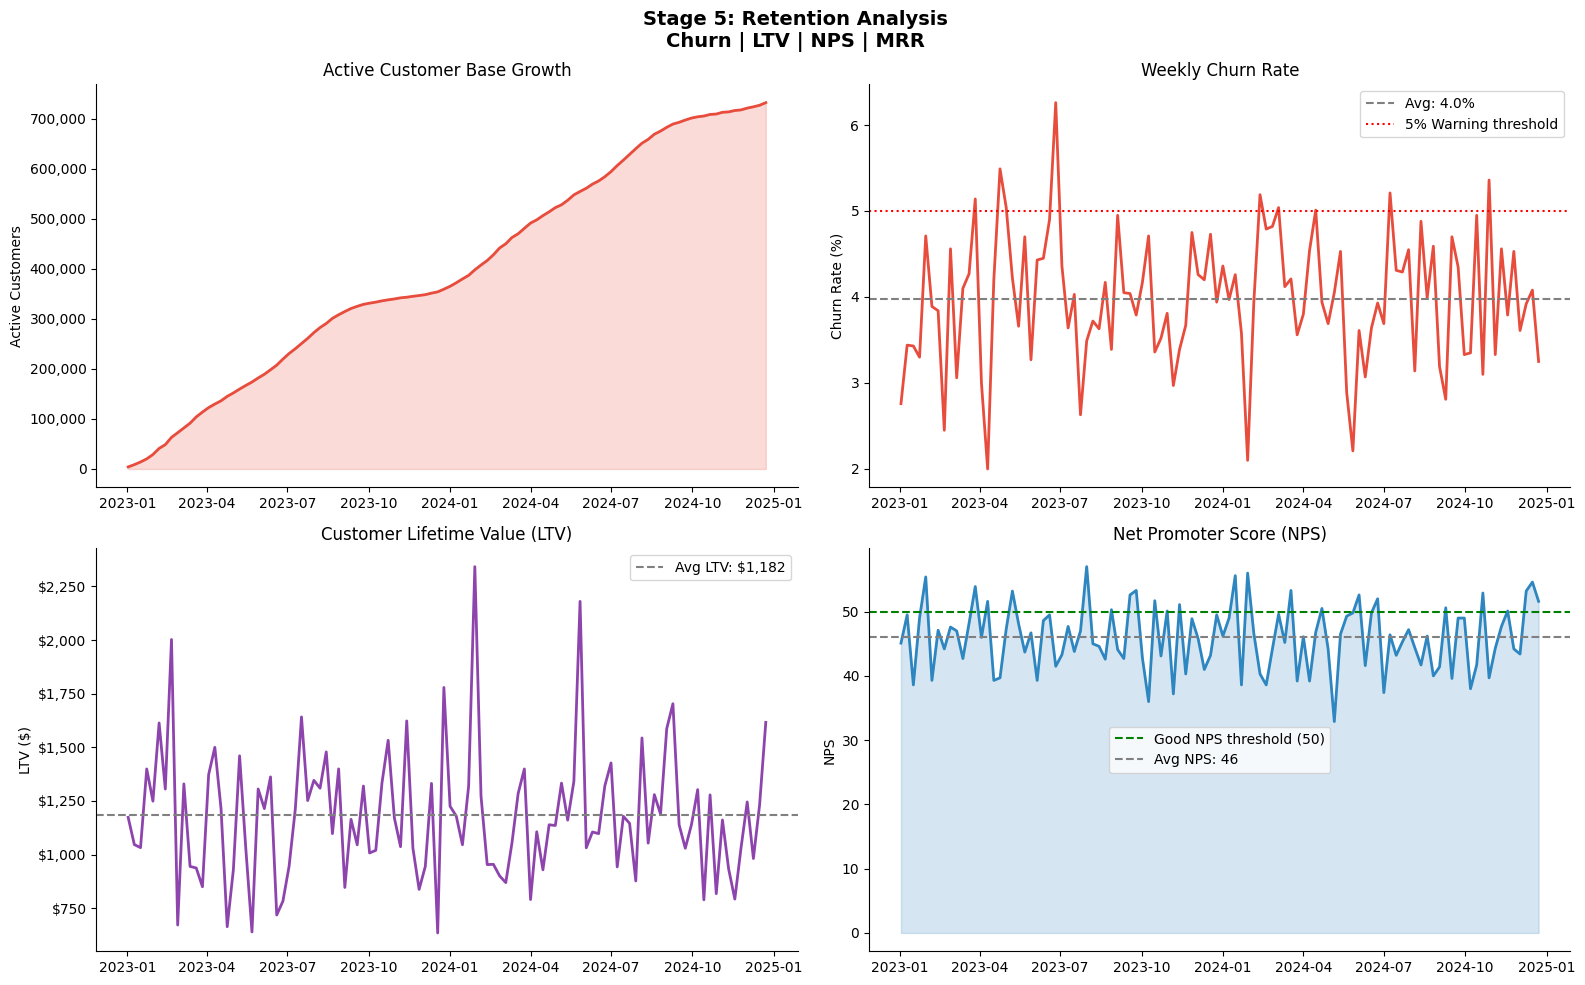

✅ Retention analysis saved!


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Stage 5: Retention Analysis\nChurn | LTV | NPS | MRR',
             fontsize=14, fontweight='bold')

# Active customers growth
axes[0,0].plot(retention['date'], retention['active_customers'],
               color=COLORS['retention'], linewidth=2)
axes[0,0].fill_between(retention['date'], retention['active_customers'],
                        alpha=0.2, color=COLORS['retention'])
axes[0,0].set_title('Active Customer Base Growth')
axes[0,0].set_ylabel('Active Customers')
axes[0,0].yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Churn rate
axes[0,1].plot(retention['date'], retention['churn_rate_pct'],
               color='#E74C3C', linewidth=2)
axes[0,1].axhline(retention['churn_rate_pct'].mean(),
                   color='gray', linestyle='--',
                   label=f"Avg: {retention['churn_rate_pct'].mean():.1f}%")
axes[0,1].axhline(5, color='red', linestyle=':',
                   linewidth=1.5, label='5% Warning threshold')
axes[0,1].set_title('Weekly Churn Rate')
axes[0,1].set_ylabel('Churn Rate (%)')
axes[0,1].legend()

# LTV trend
axes[1,0].plot(retention['date'], retention['ltv'],
               color='#8E44AD', linewidth=2)
axes[1,0].axhline(retention['ltv'].mean(),
                   color='gray', linestyle='--',
                   label=f"Avg LTV: ${retention['ltv'].mean():,.0f}")
axes[1,0].set_title('Customer Lifetime Value (LTV)')
axes[1,0].set_ylabel('LTV ($)')
axes[1,0].yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1,0].legend()

# NPS trend
axes[1,1].plot(retention['date'], retention['nps'],
               color='#2E86C1', linewidth=2)
axes[1,1].fill_between(retention['date'], retention['nps'],
                        alpha=0.2, color='#2E86C1')
axes[1,1].axhline(50, color='green', linestyle='--',
                   linewidth=1.5, label='Good NPS threshold (50)')
axes[1,1].axhline(retention['nps'].mean(),
                   color='gray', linestyle='--',
                   label=f"Avg NPS: {retention['nps'].mean():.0f}")
axes[1,1].set_title('Net Promoter Score (NPS)')
axes[1,1].set_ylabel('NPS')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('09_retention_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Retention analysis saved!")

# Cross-Funnel Correlation:

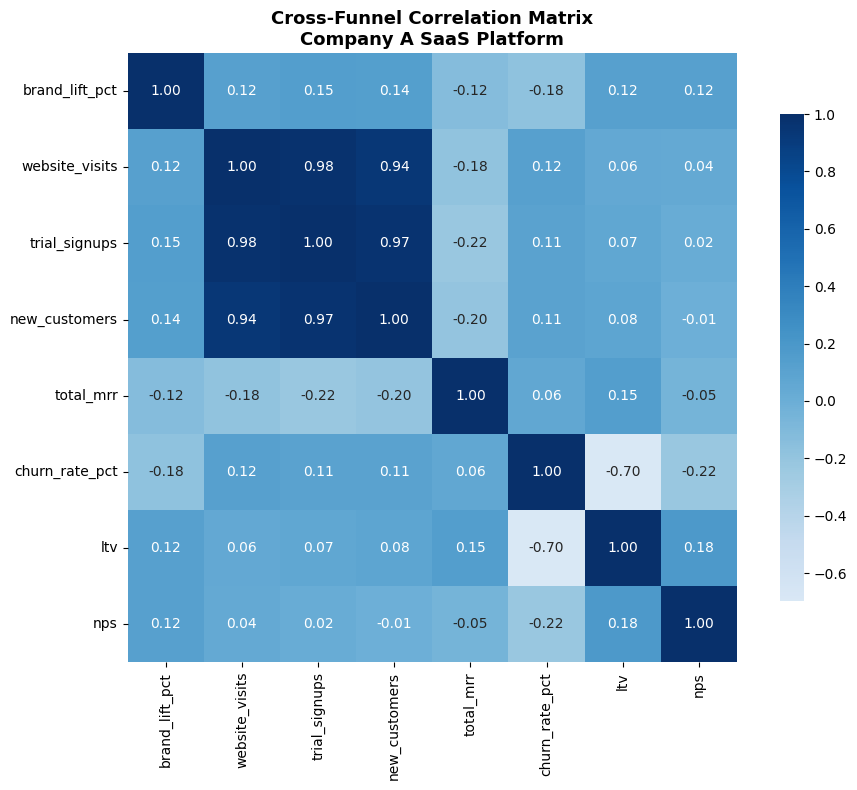

✅ Correlation matrix saved!


In [8]:
corr_data = funnel[[
    'brand_lift_pct', 'website_visits',
    'trial_signups',  'new_customers',
    'total_mrr',      'churn_rate_pct',
    'ltv',            'nps'
]].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_data,
            annot=True, fmt='.2f',
            cmap='Blues',
            center=0,
            square=True,
            ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Cross-Funnel Correlation Matrix\nCompany A SaaS Platform',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('10_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Correlation matrix saved!")

In [9]:
from google.colab import files
charts = ['05_awareness_analysis.png',
          '06_consideration_analysis.png',
          '07_intent_analysis.png',
          '08_conversion_analysis.png',
          '09_retention_analysis.png',
          '10_correlation_matrix.png']

for chart in charts:
    files.download(chart)
print("✅ All Notebook 2 charts downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All Notebook 2 charts downloaded!
